In [1]:
using BenchmarkTools

function winograd_mult(A::Matrix, B::Matrix)
    m, n = size(A)
    n2, p = size(B)
    C = zeros(eltype(A), m, p)
    
    d = n ÷ 2
    
    row_factor = zeros(eltype(A), m)
    for i in 1:m
        for j in 1:d
            row_factor[i] += A[i, 2j-1] * A[i, 2j]
        end
    end
    
    col_factor = zeros(eltype(B), p)
    for i in 1:p
        for j in 1:d
            col_factor[i] += B[2j-1, i] * B[2j, i]
        end
    end
    
    for i in 1:m
        for j in 1:p
            C[i, j] = -row_factor[i] - col_factor[j]
            for k in 1:d
                C[i, j] += (A[i, 2k-1] + B[2k, j]) * (A[i, 2k] + B[2k-1, j])
            end
        end
    end
    
    if n % 2 == 1
        for i in 1:m
            for j in 1:p
                C[i, j] += A[i, n] * B[n, j]
            end
        end
    end
    
    return C
end

function classical_mult(A::Matrix, B::Matrix)
    m, n = size(A)
    n2, p = size(B)
    C = zeros(eltype(A), m, p)
    for i in 1:m
        for j in 1:p
            for k in 1:n
                C[i, j] += A[i, k] * B[k, j]
            end
        end
    end
    return C
end


function strass(A::Matrix, B::Matrix, n_min::Int=2)
    n = size(A, 1)
    
    if n <= n_min
        return classical_mult(A, B)
    end
    
    m = n ÷ 2
    v = 1:m
    u = m+1:n
    
    A11 = A[v, v]
    A12 = A[v, u]
    A21 = A[u, v]
    A22 = A[u, u]
    
    B11 = B[v, v]
    B12 = B[v, u]
    B21 = B[u, v]
    B22 = B[u, u]
    
    P1 = strass(A11 + A22, B11 + B22, n_min)
    P2 = strass(A21 + A22, B11, n_min)
    P3 = strass(A11, B12 - B22, n_min)
    P4 = strass(A22, B21 - B11, n_min)
    P5 = strass(A11 + A12, B22, n_min)
    P6 = strass(A21 - A11, B11 + B12, n_min)
    P7 = strass(A12 - A22, B21 + B22, n_min)
    
    C11 = P1 + P4 - P5 + P7
    C12 = P3 + P5
    C21 = P2 + P4
    C22 = P1 - P2 + P3 + P6
    
    C = zeros(eltype(A), n, n)
    C[v, v] = C11
    C[v, u] = C12
    C[u, v] = C21
    C[u, u] = C22
    
    return C
end

strass (generic function with 2 methods)

In [2]:
using Plots

println("Доступно потоков: ", Threads.nthreads())

sizes = [2^k for k in 4:11] 

results = Vector{Tuple{Float64, Float64, Float64, Float64}}(undef, length(sizes))

Threads.@threads for idx in 1:length(sizes)
    n = sizes[idx]
    println("Поток $(Threads.threadid()): тестирование размера $n")
    
    A = rand(n, n)
    B = rand(n, n)
    
    t_c = @elapsed classical_mult(A, B)
    t_w = @elapsed winograd_mult(A, B)
    t_s2 = @elapsed strass(A, B, 2)      # Штрассен с n_min=2
    t_s64 = @elapsed strass(A, B, 64)    # Штрассен с n_min=64
    
    results[idx] = (t_c, t_w, t_s2, t_s64)
end

t_classic = [r[1] for r in results]
t_winograd = [r[2] for r in results]
t_strassen_2 = [r[3] for r in results]
t_strassen_64 = [r[4] for r in results]




Доступно потоков: 1
Поток 1: тестирование размера 16
Поток 1: тестирование размера 32
Поток 1: тестирование размера 64
Поток 1: тестирование размера 128
Поток 1: тестирование размера 256
Поток 1: тестирование размера 512
Поток 1: тестирование размера 1024
Поток 1: тестирование размера 2048


8-element Vector{Float64}:
  1.63e-5
  5.06e-5
  0.0004464
  0.0034697
  0.0288937
  0.3634591
  2.0507924
 11.8488869

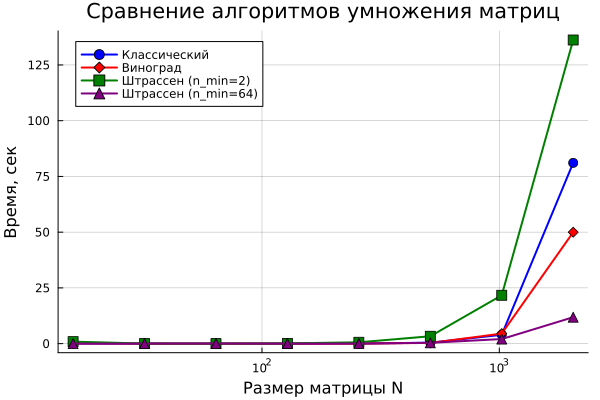

In [3]:
plot(sizes, t_classic, label="Классический", lw=2, marker=:circle, 
     color=:blue, markersize=5, xscale=:log10, grid=true, gridalpha=0.3)
plot!(sizes, t_winograd, label="Виноград", lw=2, marker=:diamond, 
      color=:red, markersize=5)
plot!(sizes, t_strassen_2, label="Штрассен (n_min=2)", lw=2, marker=:square, 
      color=:green, markersize=5)
plot!(sizes, t_strassen_64, label="Штрассен (n_min=64)", lw=2, marker=:utriangle, 
      color=:purple, markersize=5)
xlabel!("Размер матрицы N")
ylabel!("Время, сек")
title!("Сравнение алгоритмов умножения матриц")
